# 📊 Startup Success Analysis: What Drives Funding Outcomes?
By Shubham Kulkarni

## 🎯 Objective

The goal of this project is to analyze startup investment data and understand the key factors that influence startup funding success.

---

## 🔍 Problem Statement

What factors influence startup funding success?

This project aims to explore patterns in venture capital investments and identify trends related to funding, industry, geography, and time.

---
## 🧠 Approach

This project will follow a structured data analysis and machine learning workflow:

1. Data Loading and Understanding
2. Data Cleaning and Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Understanding and Relationships
5. Feature Engineering
6. Machine Learning Modeling
7. Model Evaluation
8. Insights and Business Interpretation

---

## 🤖 Machine Learning (Planned)

* Problem Type: Classification
* Goal: Predict startup funding success
* Possible Models:

  * Logistic Regression
  * Decision Tree
  * KNN

---


## Importing the required Libraries

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Dataset

In [146]:
df = pd.read_csv("investments_VC.csv", encoding='latin1')

In [147]:
df.head()

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,NaN,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [148]:
df.shape

(54294, 39)

In [149]:
df.columns

Index(['permalink', 'name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   permalink             49438 non-null  object 
 1   name                  49437 non-null  object 
 2   homepage_url          45989 non-null  object 
 3   category_list         45477 non-null  object 
 4    market               45470 non-null  object 
 5    funding_total_usd    49438 non-null  object 
 6   status                48124 non-null  object 
 7   country_code          44165 non-null  object 
 8   state_code            30161 non-null  object 
 9   region                44165 non-null  object 
 10  city                  43322 non-null  object 
 11  funding_rounds        49438 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [151]:
df.describe()

,funding_rounds,founded_year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
count,49438.000000,38482.000000,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,...,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04
mean,1.696205,2007.359129,2.173215e+05,7.501051e+06,6.163322e+03,1.302213e+05,2.336410e+04,1.888157e+06,6.541898e+04,1.628453e+05,...,3.845592e+04,7.074227e+03,1.243955e+06,1.492891e+06,1.205356e+06,7.375261e+05,3.424682e+05,1.697692e+05,5.767067e+04,1.423197e+04
std,1.294213,7.579203,1.056985e+06,2.847112e+07,1.999048e+05,2.981404e+06,1.432046e+06,1.382046e+08,6.582908e+05,5.612088e+06,...,3.864461e+06,4.282166e+05,5.531974e+06,7.472704e+06,7.993592e+06,9.815218e+06,5.406915e+06,6.277905e+06,5.252312e+06,2.716865e+06
min,1.000000,1902.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000,2006.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.000000,2010.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.000000,2012.000000,2.500000e+04,5.000000e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,18.000000,2014.000000,1.300000e+08,2.351000e+09,2.500000e+07,2.924328e+08,3.000000e+08,3.007950e+10,6.359026e+07,7.505000e+08,...,6.806116e+08,7.200000e+07,3.190000e+08,5.420000e+08,4.900000e+08,1.200000e+09,4.000000e+08,1.060000e+09,1.000000e+09,6.000000e+08


In [152]:
df.head(2).T

,0,1
permalink,/organization/waywire,/organization/tv-communications
name,#waywire,&TV Communications
homepage_url,http://www.waywire.com,http://enjoyandtv.com
category_list,|Entertainment|Politics|Social Media|News|,|Games|
market,News,Games
funding_total_usd,"17,50,000","40,00,000"
status,acquired,operating
country_code,USA,USA
state_code,NY,CA
region,New York City,Los Angeles


## First Cleaning

In [153]:
df = df.drop(columns=[
    'permalink',
    'homepage_url',
    'name'
])

In [154]:
## Clean ALL column names
df.columns = df.columns.str.strip()

In [155]:
df.columns

Index(['category_list', 'market', 'funding_total_usd', 'status',
       'country_code', 'state_code', 'region', 'city', 'funding_rounds',
       'founded_at', 'founded_month', 'founded_quarter', 'founded_year',
       'first_funding_at', 'last_funding_at', 'seed', 'venture',
       'equity_crowdfunding', 'undisclosed', 'convertible_note',
       'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
       'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A',
       'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G',
       'round_H'],
      dtype='object')

In [156]:
df['funding_total_usd'].dtype

dtype('O')

In [157]:
df['funding_total_usd'] = df['funding_total_usd'].str.replace(',', '')

In [158]:
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'], errors='coerce')

In [159]:
df['funding_total_usd'].dtype

dtype('float64')

## Understand Funding Distribution

In [160]:
df['funding_total_usd'].describe()

count    4.090700e+04
mean     1.591253e+07
std      1.686788e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

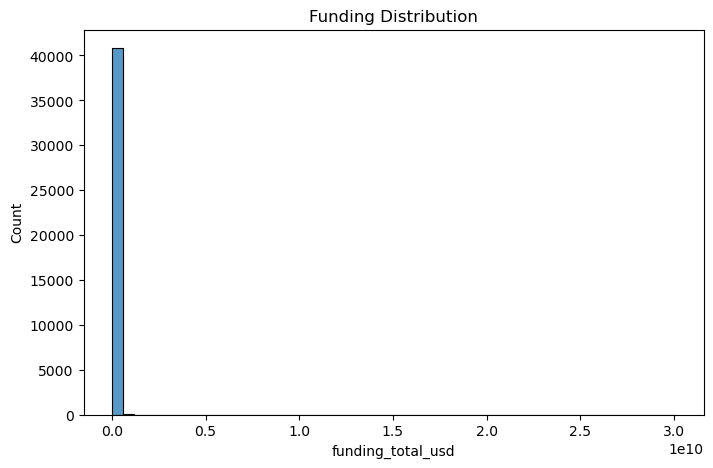

In [161]:
plt.figure(figsize=(8,5))
sns.histplot(df['funding_total_usd'], bins=50)
plt.title("Funding Distribution")
plt.show()

In [162]:
df['funding_bucket'] = pd.cut(
    df['funding_total_usd'],
    bins=[0, 1e5, 1e6, 1e7, 1e8, 1e9, 1e10],
    labels=['<100K', '100K-1M', '1M-10M', '10M-100M', '100M-1B', '1B+']
)
import warnings
warnings.filterwarnings('ignore')

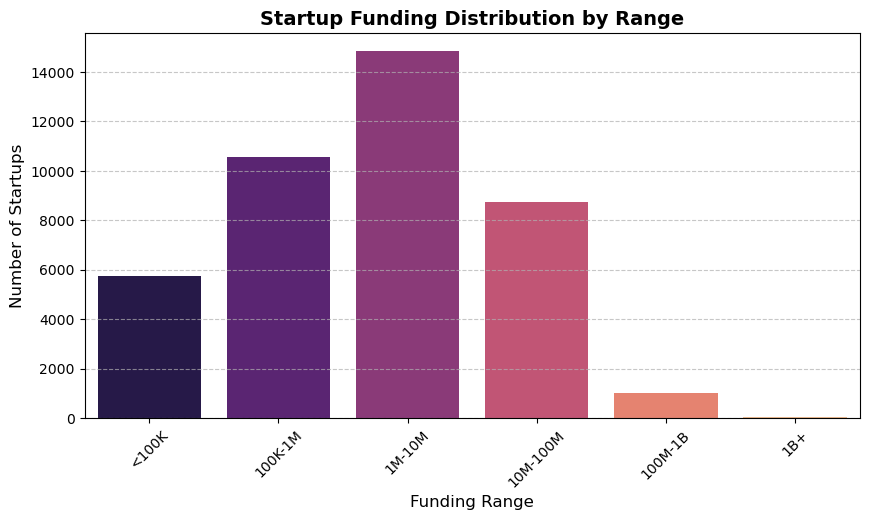

In [163]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='funding_bucket',
    data=df,
    palette='magma'   # try: 'coolwarm', 'magma', 'Set2'
)

plt.title("Startup Funding Distribution by Range", fontsize=14, fontweight='bold')
plt.xlabel("Funding Range", fontsize=12)
plt.ylabel("Number of Startups", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Funding vs Startup Success
Does more funding increase success?

* Create Target Variable

In [164]:
df['success'] = df['status'].apply(
    lambda x: 'Success' if x in ['acquired', 'operating'] else 'Failure'
)

🧠 Why This is Important

Why?
👉 A business-friendly classification variable

## Do successful startups receive more funding than failed ones?

In [165]:
df.groupby('success')['funding_total_usd'].median()

success
Failure    1055547.0
Success    2000000.0
Name: funding_total_usd, dtype: float64

In [166]:
import matplotlib.ticker as ticker

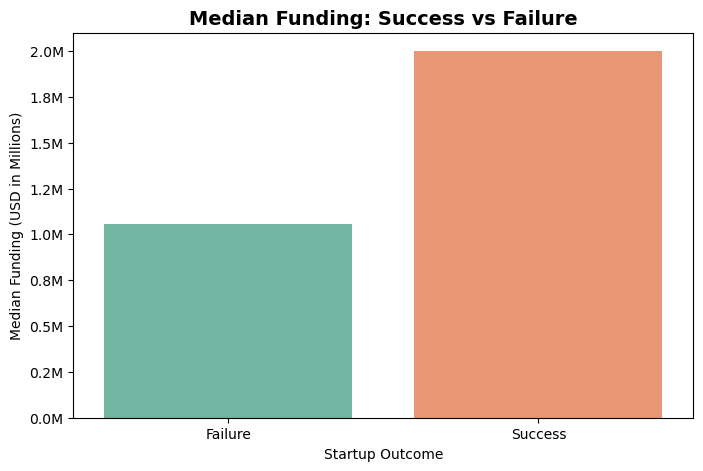

In [167]:
median_funding = df.groupby('success')['funding_total_usd'].median().reset_index()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x='success',
    y='funding_total_usd',
    data=median_funding,
    palette='Set2'
)

# Format Y-axis to Millions
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.title("Median Funding: Success vs Failure", fontsize=14, fontweight='bold')
plt.xlabel("Startup Outcome")
plt.ylabel("Median Funding (USD in Millions)")

plt.show()

## Which industries get more funding ?

In [168]:
df['main_category'] = df['category_list'].str.split('|').str[0]

In [169]:
df['category_list'].head(10)

0           |Entertainment|Politics|Social Media|News|
1                                              |Games|
2                               |Publishing|Education|
3    |Electronics|Guides|Coffee|Restaurants|Music|i...
4                        |Tourism|Entertainment|Games|
5                                           |Software|
6                                        |Advertising|
7                                        |Curated Web|
8                                           |Software|
9                                              |Games|
Name: category_list, dtype: object

In [170]:
df['category_list'].isnull().sum()

np.int64(8817)

In [171]:
df['category_list'].value_counts().head(10)

category_list
|Software|               3650
|Biotechnology|          3597
|E-Commerce|             1263
|Mobile|                 1211
|Curated Web|            1120
|Clean Technology|       1109
|Hardware + Software|     968
|Enterprise Software|     888
|Health Care|             853
|Games|                   846
Name: count, dtype: int64

In [172]:
df['main_category'] = df['category_list'].str.split('|').str[1]

In [173]:
df['main_category'].nunique()

762

In [174]:
df['main_category'].value_counts().head(10)

main_category
Software               3964
Biotechnology          3640
Mobile                 1655
E-Commerce             1508
Health Care            1221
Curated Web            1154
Clean Technology       1135
Enterprise Software     996
Hardware + Software     991
Games                   928
Name: count, dtype: int64

In [175]:
category_funding = df.groupby('main_category')['funding_total_usd'].median().sort_values(ascending=False).head(10)

## Top Funded Industries

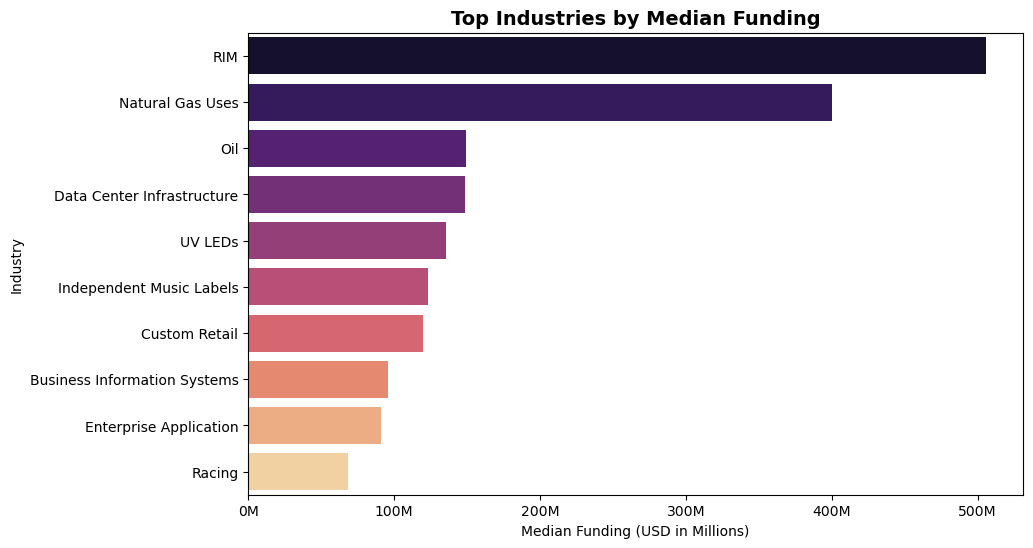

In [176]:
import matplotlib.ticker as ticker

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=category_funding.values,
    y=category_funding.index,
    palette='magma'
)

# Convert axis to Millions
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.title("Top Industries by Median Funding", fontsize=14, fontweight='bold')
plt.xlabel("Median Funding (USD in Millions)")
plt.ylabel("Industry")

plt.show()

-- 📌 Note on Metric Selection

The dataset contains extreme funding values (outliers), where a few startups receive very large investments.

To represent a typical startup more accurately, median funding is used instead of mean, as it is less affected by extreme values.


## Funding Trend Over Time
🧠 Business Question

“How has startup funding changed over the years?”

In [177]:
df['founded_year'].describe()

count    38482.000000
mean      2007.359129
std          7.579203
min       1902.000000
25%       2006.000000
50%       2010.000000
75%       2012.000000
max       2014.000000
Name: founded_year, dtype: float64

In [178]:
year_funding = df.groupby('founded_year')['funding_total_usd'].median().reset_index()

In [179]:
df['year_bucket'] = (df['founded_year'] // 5) * 5

In [180]:
year_trend = df.groupby('year_bucket')['funding_total_usd'].median().reset_index()

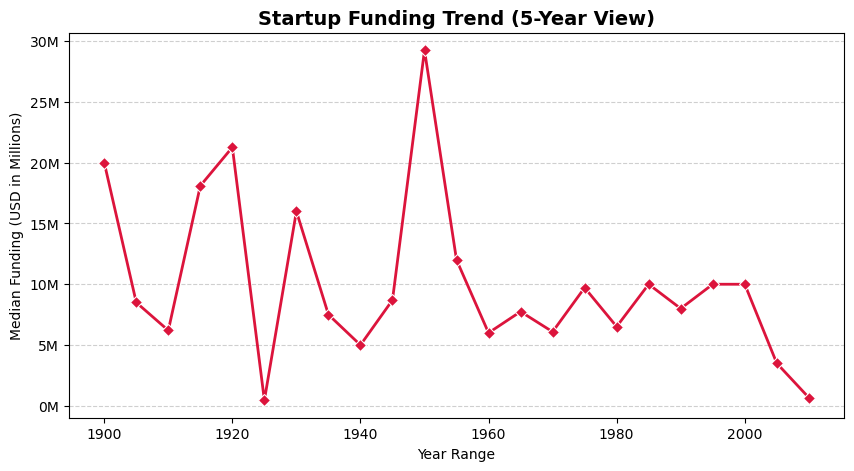

In [181]:
import matplotlib.ticker as ticker

plt.figure(figsize=(10,5))

ax = sns.lineplot(
    x='year_bucket',
    y='funding_total_usd',
    data=year_trend,
    marker='D',            
    color='crimson',         
    linewidth=2
)

# Format Y-axis in Millions
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.title("Startup Funding Trend (5-Year View)", fontsize=14, fontweight='bold')
plt.xlabel("Year Range")
plt.ylabel("Median Funding (USD in Millions)")

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

🎯 What the Graph is Saying
* 1. No consistent upward trend
Funding does not steadily increase
It fluctuates a lot
* 2. Peak around mid-1900s (your data view)
Around 1950 → highest funding (~30M)
* 3. Stabilization phase
From 1970–2000 → funding is moderate and stable (8–10M)
* 4. Recent drop (in your dataset)
After 2000 → noticeable decline

### 📊 Funding Trend Insight

Startup funding has shown significant fluctuations over time rather than a consistent upward trend.

A peak in funding is observed around the mid-20th century, followed by a relatively stable period where median funding remained moderate. In recent years within this dataset, funding appears to decline, indicating variability in investment patterns rather than continuous growth.


## How does funding change as the number of rounds increases?

In [182]:
round_funding = df.groupby('funding_rounds')['funding_total_usd'].median().reset_index()

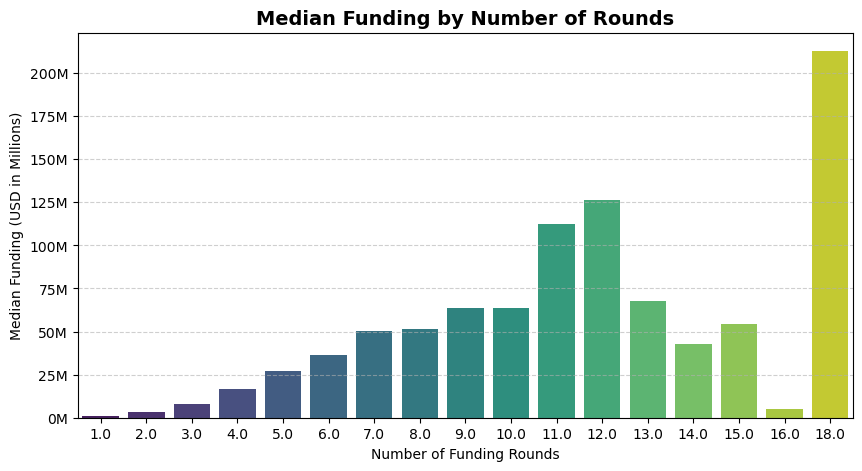

In [183]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    x='funding_rounds',
    y='funding_total_usd',
    data=round_funding,
    palette='viridis'
)

import matplotlib.ticker as ticker
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.title("Median Funding by Number of Rounds", fontsize=14, fontweight='bold')
plt.xlabel("Number of Funding Rounds")
plt.ylabel("Median Funding (USD in Millions)")

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

### 📊 Funding Rounds vs Capital Raised

Startup funding generally increases with the number of funding rounds, indicating a staged investment approach where capital is accumulated over time.

However, beyond approximately 10–12 funding rounds, the relationship becomes inconsistent, suggesting that additional rounds do not always lead to proportional increases in funding. This indicates diminishing returns in later funding stages.


## Insight: Success Rate by Industry
Which industries have higher chances of startup success?

In [184]:
industry_counts = df['main_category'].value_counts()

In [185]:
valid_industries = industry_counts[industry_counts > 50].index

In [186]:
df_filtered = df[df['main_category'].isin(valid_industries)]

In [187]:
industry_success = df_filtered.groupby('main_category')['success'].value_counts(normalize=True).unstack()

industry_success_rate = industry_success['Success'].sort_values(ascending=False).head(10)

In [188]:
df_top = df[df['main_category'].isin(
    df['main_category'].value_counts().head(10).index
)]

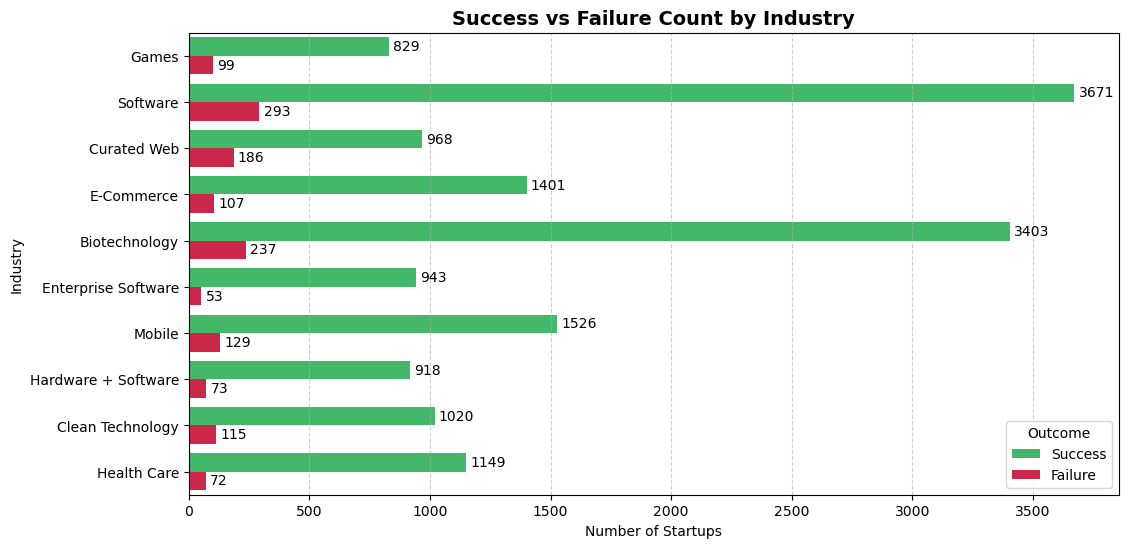

In [189]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df_top,
    y='main_category',
    hue='success',
    palette={'Success': '#2ecc61', 'Failure': '#e60c3c'}  # green & red
)

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title("Success vs Failure Count by Industry", fontsize=14, fontweight='bold')
plt.xlabel("Number of Startups")
plt.ylabel("Industry")

plt.legend(title='Outcome')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

## How many startups failed in which year and in which industry?

In [190]:
# Filter failures
df_failure = df[df['success'] == 'Failure']

# Select top industries (for readability)
top_industries = df['main_category'].value_counts().head(5).index
df_failure = df_failure[df_failure['main_category'].isin(top_industries)]

# Create failure table
failure_table = df_failure.groupby(
    ['founded_year', 'main_category']
).size().unstack().fillna(0).astype(int)

# Sort latest years first (optional)
failure_table = failure_table.sort_index(ascending=False)

# Display
failure_table.head(15)

main_category,Biotechnology,E-Commerce,Health Care,Mobile,Software
founded_year,,,,,
2013.0,1,12,3,3,5
2012.0,5,10,3,12,18
2011.0,4,17,3,21,28
2010.0,8,17,1,8,18
2009.0,4,6,4,11,20
2008.0,12,5,3,9,16
2007.0,7,5,2,5,11
2006.0,12,2,7,5,18
2005.0,10,3,1,3,10


# 🤖 Machine Learning Phase: Predicting Startup Success

## 🎯 Objective

The goal of this phase is to build a predictive model that can classify whether a startup will succeed or fail based on key features such as funding amount, number of funding rounds, and founding year.

---

## 🧠 Approach

We will start with a simple and interpretable model (Decision Tree) to:

* Predict startup success
* Understand the key factors influencing success
* Extract decision rules that explain *why* a startup succeeds or fails

---

## 📊 Features Used

* Funding Total (USD)
* Number of Funding Rounds
* Founded Year

---

## 🎯 Target Variable

* Success (1)
* Failure (0)

---

## 💡 Expected Outcome

* A model that predicts startup success
* Clear understanding of which factors influence outcomes
* Interpretable rules that explain decision-making

---


In [191]:
X = df[['funding_total_usd', 'funding_rounds', 'founded_year']]
y = df['success']

In [192]:
X.head()

,funding_total_usd,funding_rounds,founded_year
0,1750000.0,1.0,2012.0
1,4000000.0,2.0,NaN
2,40000.0,1.0,2012.0
3,1500000.0,1.0,2011.0
4,60000.0,2.0,2014.0


In [193]:
y.head()

0    Success
1    Success
2    Success
3    Success
4    Success
Name: success, dtype: object

In [194]:
X['founded_year'] = X['founded_year'].fillna(X['founded_year'].median())

In [195]:
X = X.copy()
X['founded_year'] = X['founded_year'].fillna(X['founded_year'].median())

In [196]:
y = y.map({'Success': 1, 'Failure': 0})

In [197]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: success, dtype: int64

In [198]:
y.value_counts()

success
1    45521
0     8773
Name: count, dtype: int64

## Train Decision Tree (First Model)

In [199]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [200]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## 🔍 Model Testing: Making Predictions

After training the Decision Tree model, the next step is to evaluate its performance on unseen data.

We use the test dataset (`X_test`) to generate predictions and compare them with the actual outcomes (`y_test`).

This helps us understand how well the model generalizes and whether it can reliably predict startup success or failure.

---


In [201]:
y_pred = model.predict(X_test)

## 📊 Model Evaluation

After generating predictions, we evaluate the performance of the model by comparing predicted outcomes with actual values.

This helps us measure how accurately the model is classifying startups as successful or failed.

We will use metrics such as accuracy and a classification report to assess performance in detail.

---


In [202]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9005433281149277
              precision    recall  f1-score   support

           0       0.73      0.60      0.66      1748
           1       0.93      0.96      0.94      9111

    accuracy                           0.90     10859
   macro avg       0.83      0.78      0.80     10859
weighted avg       0.89      0.90      0.90     10859



### 📊 Model Performance Insight

Although the model achieves an accuracy of 90%, it performs significantly better at predicting successful startups than failed ones.

The recall for failed startups is only 60%, indicating that the model misses a substantial number of failures. This suggests that the model is biased toward the majority class (successful startups) due to class imbalance in the dataset.

For practical applications, this limitation is critical, as identifying potential failures is often more valuable than predicting successes.


The model is biased toward the majority class (successful startups), which leads to poor detection of failures — even though overall accuracy is high.

## ⚖️ Handling Class Imbalance

The dataset contains significantly more successful startups than failed ones, which causes the model to favor the majority class.

To address this, we adjust the model by assigning balanced class weights. This ensures that both success and failure cases are treated with equal importance during training.

---


### Updated Model Code

In [203]:
model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [204]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.51      0.68      0.58      1748
           1       0.93      0.88      0.90      9111

    accuracy                           0.84     10859
   macro avg       0.72      0.78      0.74     10859
weighted avg       0.87      0.84      0.85     10859



### 📊 Improved Model Insight

After applying class balancing, the model shows improved performance in identifying failed startups. The recall for failures increased from 60% to 68%, indicating better detection of unsuccessful ventures.

However, this improvement comes with a trade-off, as overall accuracy decreased slightly. This highlights the balance between optimizing for overall accuracy and improving minority class detection.

In real-world scenarios, improving failure detection is often more valuable, making the balanced model more practical and insightful.


In [205]:
from sklearn.tree import export_text

print(export_text(model, feature_names=list(X.columns)))

|--- funding_rounds <= inf
|   |--- founded_year <= 2011.50
|   |   |--- funding_total_usd <= 1213350.00
|   |   |   |--- funding_total_usd <= 101468.50
|   |   |   |   |--- founded_year <= 2005.50
|   |   |   |   |   |--- funding_rounds <= 2.50
|   |   |   |   |   |   |--- founded_year <= 1987.50
|   |   |   |   |   |   |   |--- founded_year <= 1974.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- founded_year >  1974.50
|   |   |   |   |   |   |   |   |--- funding_total_usd <= 92500.00
|   |   |   |   |   |   |   |   |   |--- funding_total_usd <= 55000.00
|   |   |   |   |   |   |   |   |   |   |--- founded_year <= 1986.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |   |   |--- founded_year >  1986.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |   |--- funding_total_usd >  55000.00
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   

In [206]:
tree_text = export_text(model, feature_names=list(X.columns))

print("\n".join(tree_text.split("\n")[:20]))

|--- funding_rounds <= inf
|   |--- founded_year <= 2011.50
|   |   |--- funding_total_usd <= 1213350.00
|   |   |   |--- funding_total_usd <= 101468.50
|   |   |   |   |--- founded_year <= 2005.50
|   |   |   |   |   |--- funding_rounds <= 2.50
|   |   |   |   |   |   |--- founded_year <= 1987.50
|   |   |   |   |   |   |   |--- founded_year <= 1974.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- founded_year >  1974.50
|   |   |   |   |   |   |   |   |--- funding_total_usd <= 92500.00
|   |   |   |   |   |   |   |   |   |--- funding_total_usd <= 55000.00
|   |   |   |   |   |   |   |   |   |   |--- founded_year <= 1986.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |   |   |--- founded_year >  1986.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |   |--- funding_total_usd >  55000.00
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   

## 🌳 Enhancing the Model: Adding Industry Information

### 🎯 Objective

In the previous model, we used only numerical features such as funding amount, number of funding rounds, and founding year. While these provided useful insights, they do not capture the business context of the startup.

To improve the model, we now include **industry (main_category)** as a feature.

---

### 🧠 Why Add Industry?

Different industries have different:

* Growth patterns
* Risk levels
* Funding dynamics
* Market competition

For example, technology startups may scale differently compared to retail or healthcare startups.

Including industry helps the model understand these differences and make more informed predictions.

---

### ⚙️ Approach

Since machine learning models cannot directly interpret text data, we convert the categorical feature (`main_category`) into numerical format using **One-Hot Encoding**.

This creates separate binary columns for each industry.

---

### 🎯 Expected Outcome

* Improved prediction performance
* Better understanding of how industry influences success
* More realistic and business-relevant decision rules

---


In [207]:
# -- Add Industry to Features

X = df[['funding_total_usd', 'funding_rounds', 'founded_year', 'main_category']].copy()

# Handle missing values
X['founded_year'] = X['founded_year'].fillna(X['founded_year'].median())

In [208]:
### 🟢 Step 2: Convert Industry into Numbers (Encoding)

X = pd.get_dummies(X, columns=['main_category'], drop_first=True)

In [209]:
## --- Prepare Data (Target + Split)

y = df['success'].map({'Success': 1, 'Failure': 0})

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [210]:
### Train Improved Model (with Industry)

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,   # 👈 increase depth
    class_weight='balanced'
)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [211]:
## Extract Tree Rules (Top Part Only)

from sklearn.tree import export_text

tree_text = export_text(model, feature_names=list(X.columns))
print("\n".join(tree_text.split("\n")[:20]))

|--- funding_rounds <= inf
|   |--- founded_year <= 2011.50
|   |   |--- funding_total_usd <= 1213350.00
|   |   |   |--- main_category_Curated Web <= 0.50
|   |   |   |   |--- funding_total_usd <= 101468.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- funding_total_usd >  101468.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- main_category_Curated Web >  0.50
|   |   |   |   |--- founded_year <= 2003.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- founded_year >  2003.50
|   |   |   |   |   |--- class: 0
|   |   |--- funding_total_usd >  1213350.00
|   |   |   |--- funding_rounds <= 2.50
|   |   |   |   |--- founded_year <= 2001.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- founded_year >  2001.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- funding_rounds >  2.50


### 🌳 Model Insight with Industry Feature

After including industry as a feature, the model begins to incorporate business context into its decisions.

For example, startups in the **Curated Web** industry show different success patterns based on their founding year. Older startups in this category are more likely to succeed, while newer ones show a higher likelihood of failure.

This indicates that industry-specific dynamics, combined with timing, play an important role in determining startup outcomes.


### 📊 Final Insight on Feature Importance

While industry plays a role in determining startup success, it is not the primary factor in the model. Core financial indicators such as funding rounds and funding amount, along with the timing of the startup, have a stronger influence on predictions.

Industry acts as a secondary factor that refines the decision, helping the model capture more nuanced, business-specific patterns.


### 🌲 Random Forest Model

### 🎯 Objective

To improve model performance and reduce overfitting, we use a Random Forest classifier.

---

### 🧠 Why Random Forest?

A Decision Tree relies on a single model, which can lead to overfitting and unstable predictions.

Random Forest overcomes this by:

* Building multiple decision trees
* Using random subsets of data and features
* Combining predictions from all trees

---

### 🎯 Expected Outcome

* Better generalization
* Improved balance between classes
* More reliable predictions

---


## 🚀 Step 1: Train Random Forest

In [212]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=20,   # 👈 reduce from 100 → 20
    max_depth=5,       # 👈 limit complexity
    random_state=42,
    class_weight='balanced',
    n_jobs=-1          # 👈 use all CPU cores (IMPORTANT)
)

rf_model.fit(X_train, y_train)

,n_estimators,20
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Evaluate Random Forest

In [213]:
from sklearn.metrics import classification_report, accuracy_score

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.635785983976425
              precision    recall  f1-score   support

           0       0.28      0.82      0.42      1748
           1       0.94      0.60      0.73      9111

    accuracy                           0.64     10859
   macro avg       0.61      0.71      0.58     10859
weighted avg       0.84      0.64      0.68     10859



### 📊 Model Comparison: Decision Tree vs Random Forest

The Random Forest model shows a significant improvement in identifying failed startups, with recall increasing to 82%. This makes it more effective at detecting potential failures.

However, this improvement comes at the cost of overall accuracy, which drops to around 64%. The model also produces more false positives, incorrectly labeling some successful startups as failures.

In contrast, the Decision Tree model provides better overall accuracy and a more balanced performance, though it is less effective at identifying failures.

This highlights an important trade-off between accuracy and failure detection, and the choice of model should depend on the business objective.


### Which factors actually drive success/failure

In [214]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='importance', ascending=False)

feature_importance.head(10)

,feature,importance
2,founded_year,0.273070
0,funding_total_usd,0.105319
59,main_category_Biotechnology,0.075707
236,main_category_Enterprise Software,0.063063
311,main_category_Health and Wellness,0.046027
642,main_category_Software,0.042693
433,main_category_Mobile,0.040511
124,main_category_Consulting,0.030981
1,funding_rounds,0.028006
422,main_category_Medical,0.024855


### 🧠 Top Features 
### 🥇 1. founded_year (27%)

👉 Most important feature

Meaning:
Timing matters a LOT
Market conditions / era impact success
### 🥈 2. funding_total_usd (10%)

👉 Total funding is important
But:
❗ Not the biggest driver

### 🥉 3. Industry Features (Multiple entries)

Examples:

Biotechnology
Enterprise Software
Health & Wellness
Software

👉 Combined → VERY important

⚠️ Interesting Observation

👉 funding_rounds = very LOW importance (~2.8%)

❗ This is surprising because:

Earlier:

Decision Tree said it was important

Now:

Random Forest says less important
### 🧠 WHY This Difference?

👉 Decision Tree:

One path → overemphasized rounds

👉 Random Forest:

Multiple trees → more balanced view

👉 So:
✔️ Random Forest is more reliable here

### 🔥 BIG FINAL INSIGHT

👉 Real drivers:

1️⃣ Timing (founded_year)
2️⃣ Funding amount
3️⃣ Industry

👉 NOT:
❌ Just number of rounds

### 📊 Feature Importance Insight

The Random Forest model highlights that the **founding year** is the most influential factor in predicting startup success, indicating the importance of market timing and external conditions.

Total funding also plays a significant role, while industry-specific features collectively contribute to the model’s decisions, reflecting differences in success patterns across sectors.

Interestingly, the number of funding rounds has relatively low importance in this model, suggesting that while it may indicate growth, it is not a primary driver of success when considered alongside other factors.

Overall, the results emphasize that timing, funding scale, and industry context are the key determinants of startup outcomes.


### 🧠 Final Conclusion

This project was designed to answer the core question:

> **What factors influence startup funding success?**

Through data analysis and machine learning, we identified the most impactful drivers:

* **Founded Year (Timing)** → Indicates the importance of market conditions and external environment
* **Total Funding** → Reflects the scale of investor confidence
* **Industry** → Highlights sector-specific success patterns
* **Funding Rounds** → Plays a role, but is less influential than expected

---

## ⚖️ Role of Machine Learning

Machine learning models helped validate these insights:

* The **Decision Tree** provided clear and interpretable rules, helping explain how different factors influence success.
* The **Random Forest** offered more reliable predictions and revealed a more balanced view of feature importance.

---

## 🎯 Final Answer to the Problem Statement

Startup success is influenced by a combination of:

* **Market timing (founded year)**
* **Funding scale (total funding)**
* **Industry dynamics**

Rather than any single factor alone.

---

## 🧩 Model Selection Based on Use Case

### ✅ Decision Tree

Best suited for:

* Understanding decision logic
* Explaining results to stakeholders

### ✅ Random Forest

Best suited for:

* Predicting outcomes reliably
* Identifying high-risk (failing) startups

---

## 🚀 Final Takeaway

This project demonstrates that:

* Data analysis helps uncover patterns
* Machine learning helps validate and quantify them

👉 The most effective approach combines:

* **Interpretability (Decision Tree)**
* **Reliability (Random Forest)**

to both understand and predict startup success.


## 🚀 Final Summary

This project analyzed startup funding data to understand the key factors influencing success.

Through exploratory data analysis and machine learning, we identified that:

* **Market timing (founded year)** plays the most critical role
* **Total funding** significantly impacts outcomes
* **Industry** influences patterns but is not the primary driver
* **Funding rounds** are less important than expected

---

### 🤖 Model Insights

* Decision Tree provided clear and interpretable decision rules
* Random Forest improved failure detection but reduced overall accuracy

---

### 🎯 Final Recommendation

* Use **Decision Tree** for understanding and explaining decisions
* Use **Random Forest** for identifying high-risk (failing) startups

---

### 💡 Key Takeaway

Startup success is not driven by a single factor, but by a combination of:

* Timing
* Funding scale
* Industry dynamics

Understanding these relationships is essential for better investment and strategic decisions.
